In [1]:
import os
import tensorflow as tf
import numpy as np
import random

D:\Software\anaconda3\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.12.2 when it was built against 1.12.1, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


In [2]:
train_directory = "trainSub30"
test_directory = "testSub30"
val_directory = "valSub30"
class_list = ['1. Dog', '28. shallow', '32. Market', '39. famous', '4. Money', '44. Telephone', '46. you (plural)', '47. Red', '48. Hello', '50. Tool', '51. Good Morning', '52. Lamp', '54. Good night', '56. Laptop', '58. Camera', '58. Son', '62. Parent', '66. Brother', '69. Wednesday', '7. Horse', '74. Queen', '78. long', '79. Child', '8. Blind', '83. Afternoon', '84. small little', '88. cold', '9. Train', '90. Secretary', '92. old']

seed_constant = 27
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

In [3]:
def load_training_data_and_count_classes(directory):
    # Dictionary to hold class names and their corresponding video frames
    data = {}
    # Walking through the class directories
    for class_name in sorted(os.listdir(directory)):
        # Skip .DS_Store file
        if class_name == '.DS_Store':
            continue
            
        class_dir = os.path.join(directory, class_name)
        data[class_name] = []
        # Walking through the video directories within each class
        for video_name in sorted(os.listdir(class_dir)):
            # Skip .DS_Store file
            if video_name == '.DS_Store':
                continue
            
            video_dir = os.path.join(class_dir, video_name)
            video_frames = []
            for frame_name in sorted(os.listdir(video_dir)):
                # Skip .DS_Store file
                if frame_name == '.DS_Store':
                    continue
                
                frame_path = os.path.join(video_dir, frame_name)
                # Read and preprocess the frame
                frame = tf.io.read_file(frame_path)
                frame = tf.image.decode_png(frame, channels=3)
                frame = tf.image.resize(frame, [224, 224])  # Resizing to 224x224
                frame = tf.cast(frame, tf.float16) / 255.0  # Normalizing
                video_frames.append(frame)
            # Stack frames to create a single array for the video
            video_frames = tf.stack(video_frames)
            data[class_name].append(video_frames)
    
    # Count the number of classes
    num_classes = len(data.keys())
    
    return data


In [4]:
data = load_training_data_and_count_classes(train_directory)

In [5]:
def process_data_with_adjusted_window(data, class_list, sequence_length=40): 
    x_train = []
    y_train = []

    for class_name, videos in data.items():
        class_index = class_list.index(class_name)  # Get the class index

        for video_frames in videos:
            num_frames = video_frames.shape[0]

            # Skip videos with fewer than 'sequence_length' frames
            if num_frames < sequence_length:
                continue
            
            # For videos with more than 50 frames, add both the first and last 'sequence_length' frames
            if num_frames > 50:
                start_frames = video_frames[:sequence_length]
                end_frames = video_frames[-sequence_length:]
                x_train.extend([start_frames, end_frames])  # Extend to add both tensors
                y_train.extend([class_index, class_index])  # Add class index twice
            else:
                # For videos with more than 'sequence_length' but less than or equal to 50 frames,
                # add only the first 'sequence_length' frames
                first_frames = video_frames[:sequence_length]
                x_train.append(first_frames)
                y_train.append(class_index)
    
    # Convert lists to numpy arrays
    x_train = np.stack(x_train)
    y_train = np.array(y_train)

    return x_train, y_train

# Assuming 'data' is your loaded dictionary containing the class names and video frames
# And 'class_list' is your list of class names
x_train, y_train = process_data_with_adjusted_window(data, class_list, sequence_length=40)

print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")


x_train shape: (581, 40, 224, 224, 3)
y_train shape: (581,)


In [6]:
data = load_training_data_and_count_classes(val_directory)
x_val, y_val = process_data_with_adjusted_window(data, class_list, sequence_length=40)

In [7]:
print(f"x_val shape: {x_val.shape}")
print(f"y_val shape: {y_val.shape}")

x_val shape: (181, 40, 224, 224, 3)
y_val shape: (181,)


In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TimeDistributed, Conv2D, MaxPooling2D, Dropout, Flatten, LSTM, Dense, Bidirectional

SEQUENCE_LENGTH = 40  # Updated to 40 based on your dataset
IMAGE_HEIGHT, IMAGE_WIDTH = 224, 224  # Using the specified dimensions

def create_model():
    model = Sequential()
   
    model.add(TimeDistributed(Conv2D(16, (3, 3), padding='same', activation='relu'),
                              input_shape=(SEQUENCE_LENGTH, IMAGE_HEIGHT, IMAGE_WIDTH, 3)))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))
    
    model.add(TimeDistributed(Conv2D(32, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((4, 4))))
    model.add(TimeDistributed(Dropout(0.25)))
    
    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Dropout(0.25)))
    
    model.add(TimeDistributed(Conv2D(64, (3, 3), padding='same', activation='relu')))
    model.add(TimeDistributed(MaxPooling2D((2, 2))))
    model.add(TimeDistributed(Flatten()))
                                      
    # Using a Bidirectional LSTM layer
    model.add(Bidirectional(LSTM(32)))
    model.add(Dense(len(class_list), activation='softmax'))

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    
    model.summary()
    
    return model

# Create and compile the model with a Bidirectional LSTM
model = create_model()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 time_distributed (TimeDist  (None, 40, 224, 224, 16   448       
 ributed)                    )                                   
                                                                 
 time_distributed_1 (TimeDi  (None, 40, 56, 56, 16)    0         
 stributed)                                                      
                                                                 
 time_distributed_2 (TimeDi  (None, 40, 56, 56, 16)    0         
 stributed)                                                      
                                                                 
 time_distributed_3 (TimeDi  (None, 40, 56, 56, 32)    4640      
 stributed)                                                      
                                                                 
 time_distributed_4 (TimeDi  (None, 40, 14, 14, 32)    0

In [9]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_callback = ModelCheckpoint(
    'model_checkpoint.h5',
    save_best_only=True,
    monitor='val_loss',
    mode='min'
)

early_stopping_callback = EarlyStopping(monitor = 'val_loss' ,patience = 10, mode='min', restore_best_weights=True)

history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=4,  # Or even smaller if necessary
    validation_data=(x_val, y_val),
    verbose=1,
    callbacks=[early_stopping_callback, checkpoint_callback]
)


Epoch 1/100
146/146 [==============================] - 99s 654ms/step - loss: 3.4053 - accuracy: 0.0344 - val_loss: 3.3812 - val_accuracy: 0.0497
Epoch 2/100


C:\Users\prath\AppData\Roaming\Python\Python310\site-packages\keras\src\engine\training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


146/146 [==============================] - 92s 628ms/step - loss: 3.3368 - accuracy: 0.0568 - val_loss: 3.1350 - val_accuracy: 0.0829
Epoch 3/100
146/146 [==============================] - 91s 626ms/step - loss: 2.8675 - accuracy: 0.1497 - val_loss: 2.8370 - val_accuracy: 0.1878
Epoch 4/100
146/146 [==============================] - 92s 634ms/step - loss: 2.5119 - accuracy: 0.2530 - val_loss: 2.4502 - val_accuracy: 0.2652
Epoch 5/100
146/146 [==============================] - 92s 629ms/step - loss: 2.1878 - accuracy: 0.3253 - val_loss: 2.2103 - val_accuracy: 0.3204
Epoch 6/100
146/146 [==============================] - 94s 644ms/step - loss: 1.8408 - accuracy: 0.4406 - val_loss: 2.0241 - val_accuracy: 0.3425
Epoch 7/100
146/146 [==============================] - 94s 644ms/step - loss: 1.5799 - accuracy: 0.5318 - val_loss: 1.8506 - val_accuracy: 0.4199
Epoch 8/100
146/146 [==============================] - 92s 631ms/step - loss: 1.3722 - accuracy: 0.6162 - val_loss: 1.7735 - val_accurac

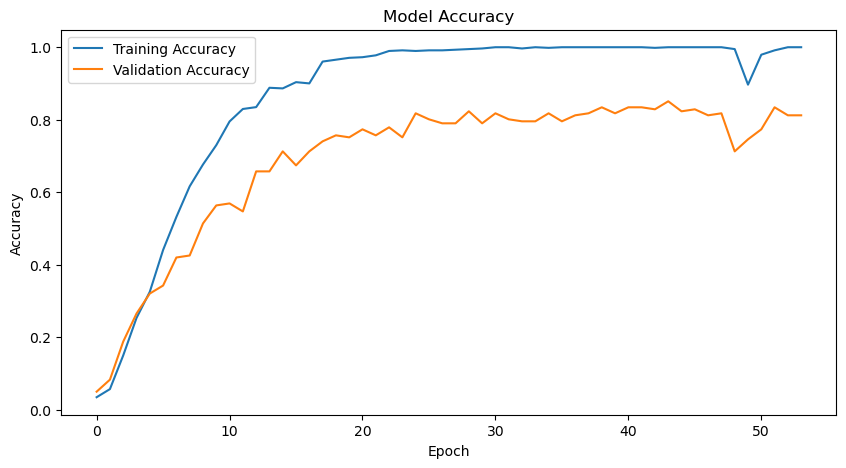

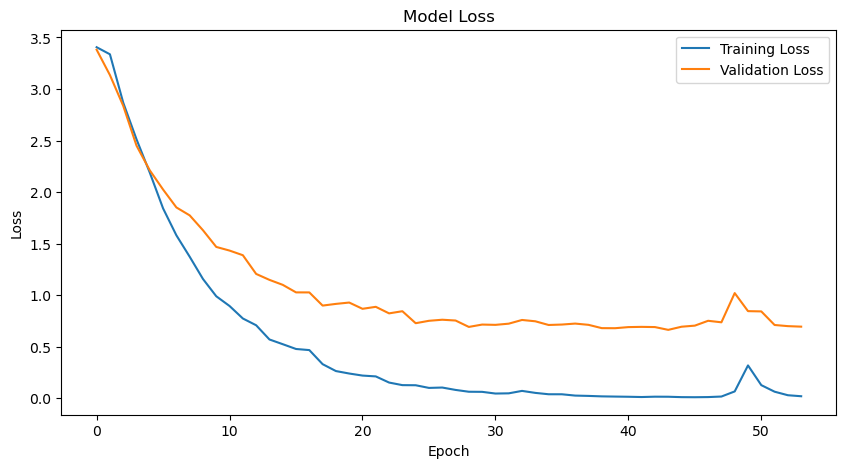

In [10]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

# Plot training & validation loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.show()


In [12]:
from tensorflow.keras.models import load_model
import numpy as np

# Load your test data
# Ensure your load_test_data function is implemented correctly to match your dataset
data = load_training_data_and_count_classes(test_directory)
x_test, y_test = process_data_with_adjusted_window(data, class_list, sequence_length=40)


4/4 [==============================] - 6s 875ms/step


NameError: name 'accuracy_score' is not defined

In [13]:
# Load the best model
model = load_model('model_checkpoint.h5')

# Make predictions on the test data
predictions = model.predict(x_test)
# Assuming predictions and y_test are already defined
predicted_classes = np.argmax(predictions, axis=1)

# Calculate accuracy manually
correct_predictions = np.sum(predicted_classes == y_test)
total_predictions = y_test.shape[0]
accuracy = correct_predictions / total_predictions

print(f"Test Accuracy: {accuracy * 100:.2f}%")

4/4 [==============================] - 5s 902ms/step
Test Accuracy: 85.05%


In [14]:
print(f"x_val shape: {x_test.shape}")
print(f"y_val shape: {y_test.shape}")

x_val shape: (107, 40, 224, 224, 3)
y_val shape: (107,)
